# Técnicas de Limpieza

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ymeza@ubiobio.cl

**Fecha de Creación:** Marzo de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece una comparación del antes y el después del proceso de limpieza de datos.

Además, se introduce el concepto de pipeline como buena práctica de la industria. En este caso se define un pipeline para el proceso de limpieza.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/Programacion_para_ciencia_de_datos/master/data/dataset_notas_estudiantes.csv

--2026-04-10 03:46:23--  https://raw.githubusercontent.com/JaznaLaProfe/Programacion_para_ciencia_de_datos/master/data/dataset_notas_estudiantes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82547 (81K) [text/plain]
Saving to: ‘dataset_notas_estudiantes.csv’

dataset_notas_estud 100%[===================>]  80.61K  --.-KB/s    in 0.009s  

2026-04-10 03:46:23 (9.02 MB/s) - ‘dataset_notas_estudiantes.csv’ saved [82547/82547]



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

In [ ]:
# Carga el set de datos
data = pd.read_csv('dataset_notas_estudiantes.csv')

## Revisión del estado

In [ ]:
# Cantidad de observaciones y columnas
data.shape

(1580, 8)

## Valores faltantes y tipos de datos

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         1580 non-null   int64  
 1   programa           1580 non-null   object 
 2   genero             1453 non-null   object 
 3   colegio_origen     1452 non-null   object 
 4   asistencia_pct     1580 non-null   float64
 5   nota_matematicas   1457 non-null   float64
 6   nota_programacion  1452 non-null   float64
 7   nota_estadistica   1454 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 98.9+ KB


## Existencia de duplicados

In [ ]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(80)

In [ ]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)].sort_values(by='student_id')

,student_id,programa,genero,colegio_origen,asistencia_pct,nota_matematicas,nota_programacion,nota_estadistica
37,38,Ingeniería,No especifica,Particular,89.7,5.11,5.91,3.50
1537,38,Ingeniería,No especifica,Particular,89.7,5.11,5.91,3.50
1538,54,Diseño,M,Subvencionado,78.5,6.50,NaN,6.20
53,54,Diseño,M,Subvencionado,78.5,6.50,NaN,6.20
75,76,Data Science,No especifica,Municipal,69.4,4.97,5.72,3.11
...,...,...,...,...,...,...,...,...
1431,1432,Ingeniería,M,Subvencionado,82.7,4.87,6.92,5.10
1460,1461,Ingeniería,No especifica,Municipal,69.6,4.95,4.35,4.68
1548,1461,Ingeniería,No especifica,Municipal,69.6,4.95,4.35,4.68
1522,1465,Administración,M,Subvencionado,82.6,5.19,4.57,5.24


## Existencia de valores atípicos (outliers)

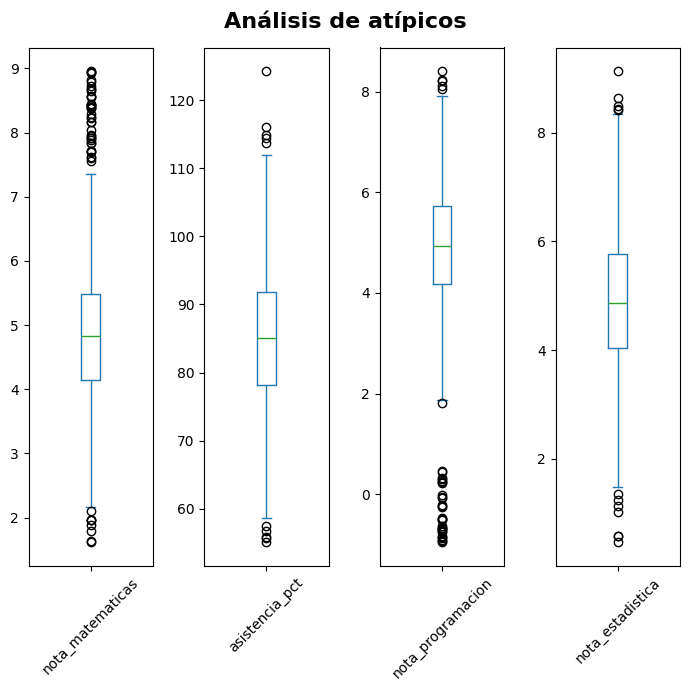

In [ ]:
revision_atipicos = ['nota_matematicas', 'asistencia_pct', 'nota_programacion',	'nota_estadistica']
fig, axes = plt.subplots(1, 4, figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Revisión de inconsistencias

In [ ]:
# Detectar inconsistencias
inconsistentes = data[(data["nota_matematicas"] <= 0) | ((data["asistencia_pct"] < 0) | (data["asistencia_pct"] > 100)) | (data["nota_programacion"] < 0) | (data["nota_estadistica"] <= 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,student_id,programa,genero,colegio_origen,asistencia_pct,nota_matematicas,nota_programacion,nota_estadistica
7,8,Ingeniería,No especifica,NaN,105.9,4.87,6.980000,5.83
10,11,Administración,F,Subvencionado,105.2,NaN,-0.680983,4.12
17,18,Diseño,F,Municipal,100.3,3.95,2.850000,5.07
20,21,Data Science,No especifica,Subvencionado,80.7,6.08,-0.686209,2.79
24,25,Diseño,NaN,Municipal,105.2,6.02,5.610000,NaN
...,...,...,...,...,...,...,...,...
1434,1435,Diseño,No especifica,Municipal,105.5,5.05,6.000000,NaN
1456,1457,Data Science,M,Municipal,104.0,5.49,4.280000,4.50
1491,1492,Administración,No especifica,Municipal,107.1,3.67,5.330000,3.99
1555,1180,Administración,F,Municipal,100.9,4.27,6.400000,4.98


## Revisión de inconsistencias para cualitativas

In [ ]:
data.colegio_origen.unique()

array(['Particular', 'Subvencionado', 'Municipal', nan], dtype=object)

In [ ]:
data.genero.unique()

array(['No especifica', 'M', 'F', nan], dtype=object)

In [ ]:
data.programa.unique()

array(['Administración', 'Diseño', 'Ingeniería', 'Data Science'],
      dtype=object)

## Estadísticas antes de la limpieza

In [ ]:
# Muestra las medidas estadísticas, descartando la columna que identifica al estudiante
data.drop(columns=['student_id']).describe()

,asistencia_pct,nota_matematicas,nota_programacion,nota_estadistica
count,1580.000000,1457.000000,1452.000000,1454.000000
mean,85.067532,4.857681,4.858785,4.894292
std,10.040457,1.122846,1.337945,1.268746
min,55.100000,1.620000,-0.951447,0.470000
25%,78.100000,4.140000,4.170000,4.030000
50%,85.100000,4.830000,4.930000,4.860000
75%,91.800000,5.490000,5.720000,5.760000
max,124.300000,8.959219,8.410000,9.130000


In [ ]:
data.describe(include="object")

,programa,genero,colegio_origen
count,1580,1453,1452
unique,4,3,3
top,Ingeniería,M,Municipal
freq,416,491,509


## Tratamiento de inconsistencias

In [ ]:
# Limitar asistencia entre 0 y 100
data["asistencia_pct"] = data["asistencia_pct"].clip(0, 100)

# Limitar notas con mínimo 1
cols_notas = ["nota_matematicas", "nota_programacion", "nota_estadistica"]
data[cols_notas] = data[cols_notas].clip(lower=1)

In [ ]:
def feature_engineering(data: pd.DataFrame):
  """
  Realiza ingeniería de características

  Parámetros
  ----------
  data: DataFrame conteniendo los datos

  Retorno
  -------
  DataFrame con las nuevas características
  """
  data = data.copy()

  data["promedio_notas"] = data[
        ["nota_matematicas", "nota_programacion", "nota_estadistica"]
    ].mean(axis=1)

  data["gap_prog_math"] = data["nota_programacion"] - data["nota_matematicas"]

  return data

In [ ]:
data_fe = feature_engineering(data.copy())

In [ ]:
data_fe["aprueba_todo"] = (
    (data_fe["nota_matematicas"] >= 4) &
    (data_fe["nota_programacion"] >= 4) &
    (data_fe["nota_estadistica"] >= 4)
).astype(int)

In [ ]:
data_corr = pd.get_dummies(
    data_fe,
    columns=["genero", "programa", "colegio_origen"],
    drop_first=True
)

In [ ]:
target = "aprueba_todo"
correlaciones = data_corr.drop(columns=["student_id"]).corr()[target].round(4)
correlaciones

,aprueba_todo
asistencia_pct,-0.0244
nota_matematicas,0.2846
nota_programacion,0.2812
nota_estadistica,0.3485
promedio_notas,0.4554
gap_prog_math,0.0109
aprueba_todo,1.0000
genero_M,-0.0215
genero_No especifica,0.0345
programa_Data Science,-0.0104


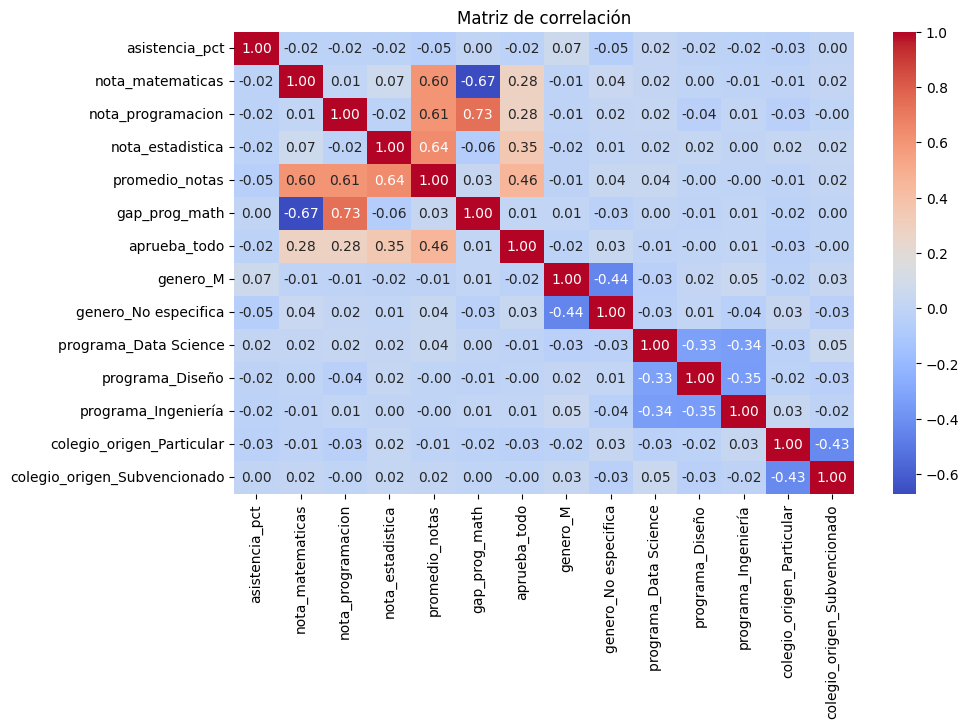

In [ ]:
correlaciones = data_corr.drop(columns=["student_id"]).corr().round(4)
plt.figure(figsize=(10, 6))
sb.heatmap(correlaciones, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [ ]:
data_fe.groupby("programa")["aprueba_todo"].mean()

,aprueba_todo
programa,
Administración,0.383598
Data Science,0.375321
Diseño,0.382872
Ingeniería,0.394231


## Limpieza

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [ ]:
def eliminar_duplicados(X : pd.DataFrame):
  """
  Tratamiento de duplicados

  Parámetros
  ----------

  X: set de datos

  Retorno
  -------
  Nuevo set de datos SIN los duplicados

  """
  return X.drop_duplicates()

In [ ]:
X = data_fe.drop(columns=["aprueba_todo", "student_id"])
y = data_fe["aprueba_todo"]

In [ ]:
# Define las variables cualitativas y cuantitativas disponibles
numeric_features = ['nota_matematicas', 'nota_programacion',	'nota_estadistica']
categorical_features = ["genero", "programa", "colegio_origen"]

In [ ]:
# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean")),
        ("escalado", StandardScaler())
    ]
)

In [ ]:
# Define el pipeline para las variables cualitativas
pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

In [ ]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

In [ ]:
# Define el pipeline de limpieza y transformación
pipeline_limpieza_transformacion = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados)),
        ("feature_engineering", FunctionTransformer(feature_engineering)),
        ("preprocesamiento", preprocesador)
    ]
)

In [ ]:
X_clean = pipeline_limpieza_transformacion.fit_transform(X)

In [ ]:
# Crea el Dataframe con los datos limpios y transformados
data_clean = pd.DataFrame(
    X_clean,
    columns=pipeline_limpieza_transformacion.named_steps["preprocesamiento"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat__", "")
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

In [ ]:
data_clean.head()

,nota_matematicas,nota_programacion,nota_estadistica,genero_F,genero_M,genero_No especifica,programa_Administración,programa_Data Science,programa_Diseño,programa_Ingeniería,colegio_origen_Municipal,colegio_origen_Particular,colegio_origen_Subvencionado
0,-0.163104,-0.729422,0.428016,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.959635,-1.119651,0.771274,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.118757,0.421756,0.274453,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.943459,-1.275743,-0.710157,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000000,-0.358703,0.409949,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
data_clean.shape

(1500, 13)

In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   nota_matematicas              1500 non-null   float64
 1   nota_programacion             1500 non-null   float64
 2   nota_estadistica              1500 non-null   float64
 3   genero_F                      1500 non-null   float64
 4   genero_M                      1500 non-null   float64
 5   genero_No especifica          1500 non-null   float64
 6   programa_Administración       1500 non-null   float64
 7   programa_Data Science         1500 non-null   float64
 8   programa_Diseño               1500 non-null   float64
 9   programa_Ingeniería           1500 non-null   float64
 10  colegio_origen_Municipal      1500 non-null   float64
 11  colegio_origen_Particular     1500 non-null   float64
 12  colegio_origen_Subvencionado  1500 non-null   float64
dtypes: 

## Estadísticas después de la limpieza

In [ ]:
data_clean.describe()

,nota_matematicas,nota_programacion,nota_estadistica,genero_F,genero_M,genero_No especifica,programa_Administración,programa_Data Science,programa_Diseño,programa_Ingeniería,colegio_origen_Municipal,colegio_origen_Particular,colegio_origen_Subvencionado
count,1.500000e+03,1.500000e+03,1.500000e+03,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,5.921189e-16,2.842171e-16,8.289665e-18,0.306667,0.390667,0.302667,0.239333,0.244000,0.254000,0.262667,0.405333,0.30000,0.294667
std,1.000334e+00,1.000334e+00,1.000334e+00,0.461264,0.488063,0.459565,0.426819,0.429636,0.435443,0.440230,0.491120,0.45841,0.456045
min,-1.926485e+00,-1.995717e+00,-1.876333e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,-6.698230e-01,-6.245474e-01,-6.920909e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,6.613403e-01,6.851608e-01,7.080422e-01,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000
max,1.959635e+00,1.825607e+00,1.882799e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


## Comentarios finales

+ *Primero pienso variables como analista, después las preparo como ingeniero para el modelo.*
+ *Escalar no destruye la información… pero sí puede destruir su significado*
+ Una pregunta de cierre: *Un analista decide normalizar las notas antes de calcular si un estudiante aprueba o reprueba. ¿Es correcto? Justifique.*

**EDA (fuera del pipeline)**

    + feature engineering manual
    + análisis de correlación
    + análisis por grupos

**MODELADO (con pipeline)**

    + limpieza
    + encoding
    + escalado
    + modelo